In [17]:
from pathlib import Path
from IPython.display import display, Markdown

from resources.imports import *
try:
    import torch
except ModuleNotFoundError:
    torch = None

from resources.MLmetrics import (
    postprocess_list_runs,
    postprocess_artifact_table,
    postprocess_load_curve_run,
    postprocess_curve_run_overview,
    display_curve_run_overview,
    postprocess_build_active_curve_diagnostics,
    curve_summary_table,
    display_curve_main_dashboard,
    display_curve_pointwise_summary,
    display_curve_sample_error_summary,
    display_curve_peak_energy_summary,
    display_curve_zone_summary,
    display_curve_sample_examples,
    display_curve_loss_component_breakdown,
    plot_curve_all_point_parity,
    display_curve_initial_slope_summary,
    plot_loss_history,
)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [18]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Find Recent Runs


In [19]:
FIND_RUN = False
RUN_ROOT = Path(r"Z:/p2")
MAX_RECENT_RUNS = 25


if FIND_RUN:
    recent_runs = postprocess_list_runs(RUN_ROOT, max_runs=MAX_RECENT_RUNS, include_hpo=True)
    display(recent_runs)
    if recent_runs.empty:
        raise ValueError("No saved runs were found. Set RUN_PATH manually.")


## 2. User Configuration


In [20]:
mechMode = "FT"
output_kind = "FieldToCurve"
model = "Transformer"
run_name = f"f2c{mechMode}full"
VIEW_MODE = mechMode
run_type = "full_hpo" if "fHPO" in run_name else "model_hpo" if "mHPO" in run_name else "standard"  # "standard", "model_hpo", or "full_hpo"
ACTIVE_SPLIT = "test" if run_type.lower() == "standard" else "val"
RUN_PATH_OVERRIDE = None


if RUN_PATH_OVERRIDE is not None:
    RUN_PATH = Path(RUN_PATH_OVERRIDE)
elif run_type == "standard":
    RUN_PATH = RUN_ROOT / mechMode / output_kind / model / run_name
elif run_type == "model_hpo":
    RUN_PATH = RUN_ROOT / mechMode / output_kind / model / "HPO" / run_name
elif run_type == "full_hpo":
    RUN_PATH = RUN_ROOT / mechMode / output_kind / "HPO" / run_name / model
else:
    raise ValueError("run_type must be 'standard', 'model_hpo', or 'full_hpo'.")

DATA_PATH_OVERRIDE = None
PREFER_HPO_BEST = True
ZONE_BOUNDARIES = None

if VIEW_MODE is None:
    VIEW_MODE = mechMode if str(mechMode).upper() in ["UT", "FT"] else "UT"
VIEW_MODE = str(VIEW_MODE).upper()
if VIEW_MODE not in ["UT", "FT"]:
    raise ValueError("VIEW_MODE must be UT or FT. For MULTI runs, choose which output branch to view.")

DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"

## 3. Load Run Artifacts


In [21]:
LOAD_DATA = False
LOAD_MODEL = False

ARTIFACT_TABLE_KEYS = None

artifacts, loaded, DAT, MOD = postprocess_load_curve_run(
    RUN_PATH,
    run_root=RUN_ROOT,
    prefer_hpo_best=PREFER_HPO_BEST,
    load_data=LOAD_DATA,
    load_model=LOAD_MODEL,
    data_path_override=DATA_PATH_OVERRIDE,
    device=DEVICE,
)


display(postprocess_artifact_table(artifacts, keys=ARTIFACT_TABLE_KEYS))
for warning in artifacts.get("warnings", []):
    print("WARNING:", warning)


Loaded DATA from: Z:\p2\FT\FieldToCurve\Transformer\f2cFTfull\model_data.json
DATA input_kind: field
DATA output_kind: curve
DATA kind: FieldToCurve
Loaded MODEL from: Z:\p2\FT\FieldToCurve\Transformer\f2cFTfull\model.json


,artifact,path_or_value
0,input_path,Z:\p2\FT\FieldToCurve\Transformer\f2cFTfull
1,run_dir,Z:\p2\FT\FieldToCurve\Transformer\f2cFTfull
2,model_json,Z:\p2\FT\FieldToCurve\Transformer\f2cFTfull\mo...
3,model_mdl,Z:\p2\FT\FieldToCurve\Transformer\f2cFTfull\mo...
4,data_json,Z:\p2\FT\FieldToCurve\Transformer\f2cFTfull\mo...
5,results_dir,Z:\p2\FT\FieldToCurve\Transformer\f2cFTfull\re...
6,metrics_json,Z:\p2\FT\FieldToCurve\Transformer\f2cFTfull\re...
7,predictions_npz,Z:\p2\FT\FieldToCurve\Transformer\f2cFTfull\re...
8,loss_history_csv,Z:\p2\FT\FieldToCurve\Transformer\f2cFTfull\re...
9,diagnostics_summary_json,Z:\p2\FT\FieldToCurve\Transformer\f2cFTfull\re...


## 4. Run Setup And Available Outputs


In [22]:
SHOW_RUN_OVERVIEW = False


overview = postprocess_curve_run_overview(
    artifacts,
    loaded,
    data=DAT,
    run_name=run_name,
    run_type=run_type,
    mech_mode=mechMode,
    view_mode=VIEW_MODE,
    model_name=model,
    device=DEVICE,
    active_split=ACTIVE_SPLIT,
)


available_evals = overview["available_evals"]
available_curve_evals = overview["available_curve_evals"]
ACTIVE_SPLIT = overview["active_split"]

if SHOW_RUN_OVERVIEW:
    display_curve_run_overview(overview)
print("mechMode:", mechMode)
print("VIEW_MODE:", VIEW_MODE)
print("ACTIVE_SPLIT:", ACTIVE_SPLIT)


mechMode: FT
VIEW_MODE: FT
ACTIVE_SPLIT: test


## 5. Build Active Curve Diagnostics


In [23]:
KEY_DIAGNOSTIC_METRICS = [
    "rmse",
    "mae",
    "bias",
    "nrmse_range",
    "r2_global",
    "collapse_ratio",
    "mean_curve_baseline_rmse",
    "skill_vs_mean_curve_rmse",
    "mean_sample_curve_corr",
    "peak_corr",
    "peak_x_corr",
    "energy_corr",
    "n_samples",
    "n_points",
]

DIAGNOSTIC_LABELS = {
    "rmse": "RMSE",
    "mae": "MAE",
    "bias": "bias",
    "nrmse_range": "NRMSE / range",
    "r2_global": "global R2",
    "collapse_ratio": "collapse ratio",
    "mean_curve_baseline_rmse": "mean-curve RMSE",
    "skill_vs_mean_curve_rmse": "skill vs mean curve",
    "mean_sample_curve_corr": "mean sample curve corr.",
    "peak_corr": "peak corr.",
    "peak_x_corr": "peak-x corr.",
    "energy_corr": "energy corr.",
    "n_samples": "samples",
    "n_points": "curve points",
}

ZONE_COLUMNS = {
    "zone": "zone",
    "x_start": "x start",
    "x_end": "x end",
    "rmse": "RMSE",
    "mae": "MAE",
    "collapse_ratio": "collapse ratio",
}


diagnostics, active_key, active_diag = postprocess_build_active_curve_diagnostics(
    DAT,
    loaded,
    available_evals,
    view_mode=VIEW_MODE,
    active_split=ACTIVE_SPLIT,
    model=MOD,
    zone_boundaries=ZONE_BOUNDARIES,
)


if active_diag is None:
    print("No active diagnostics are available. Check predictions.npz, diagnostic CSVs, VIEW_MODE, or ACTIVE_SPLIT.")
else:
    display(Markdown(f"**Active diagnostics:** `{active_key[0]} {active_key[1].upper()}`"))

    summary_table = curve_summary_table(active_diag, metrics=KEY_DIAGNOSTIC_METRICS).copy()
    summary_table["metric"] = summary_table["metric"].replace(DIAGNOSTIC_LABELS)
    summary_table["value"] = summary_table["value"].map(
        lambda value: f"{value:.4g}"
        if isinstance(value, (int, float, np.integer, np.floating)) and np.isfinite(value)
        else value
    )
    display(summary_table)

    zone_table = active_diag.get("zone_metrics")
    if zone_table is not None and not zone_table.empty:
        display(Markdown("**Zone diagnostics**"))
        zone_table = zone_table[list(ZONE_COLUMNS)].rename(columns=ZONE_COLUMNS).copy()
        zone_table["zone"] = zone_table["zone"].str.replace("_", " ").str.title()
        for column in ["x start", "x end", "RMSE", "MAE", "collapse ratio"]:
            zone_table[column] = zone_table[column].map(lambda value: f"{value:.4g}" if pd.notna(value) else value)
        display(zone_table)


**Active diagnostics:** `FT TEST`

,metric,value
0,RMSE,4233
1,MAE,2661
2,bias,-442.9
3,NRMSE / range,0.04547
4,global R2,0.9556
5,collapse ratio,0.7413
6,mean-curve RMSE,7916
7,skill vs mean curve,0.4653
8,mean sample curve corr.,0.9807
9,peak corr.,0.8918


**Zone diagnostics**

,zone,x start,x end,RMSE,MAE,collapse ratio
0,Elastic,0,6.384,1331,737.9,0.6643
1,Peak Region,6.46,12.08,4844,3548,0.8299
2,Post Peak,12.16,15.2,6421,5026,0.5997


## 6. Main Curve Diagnostic Dashboard


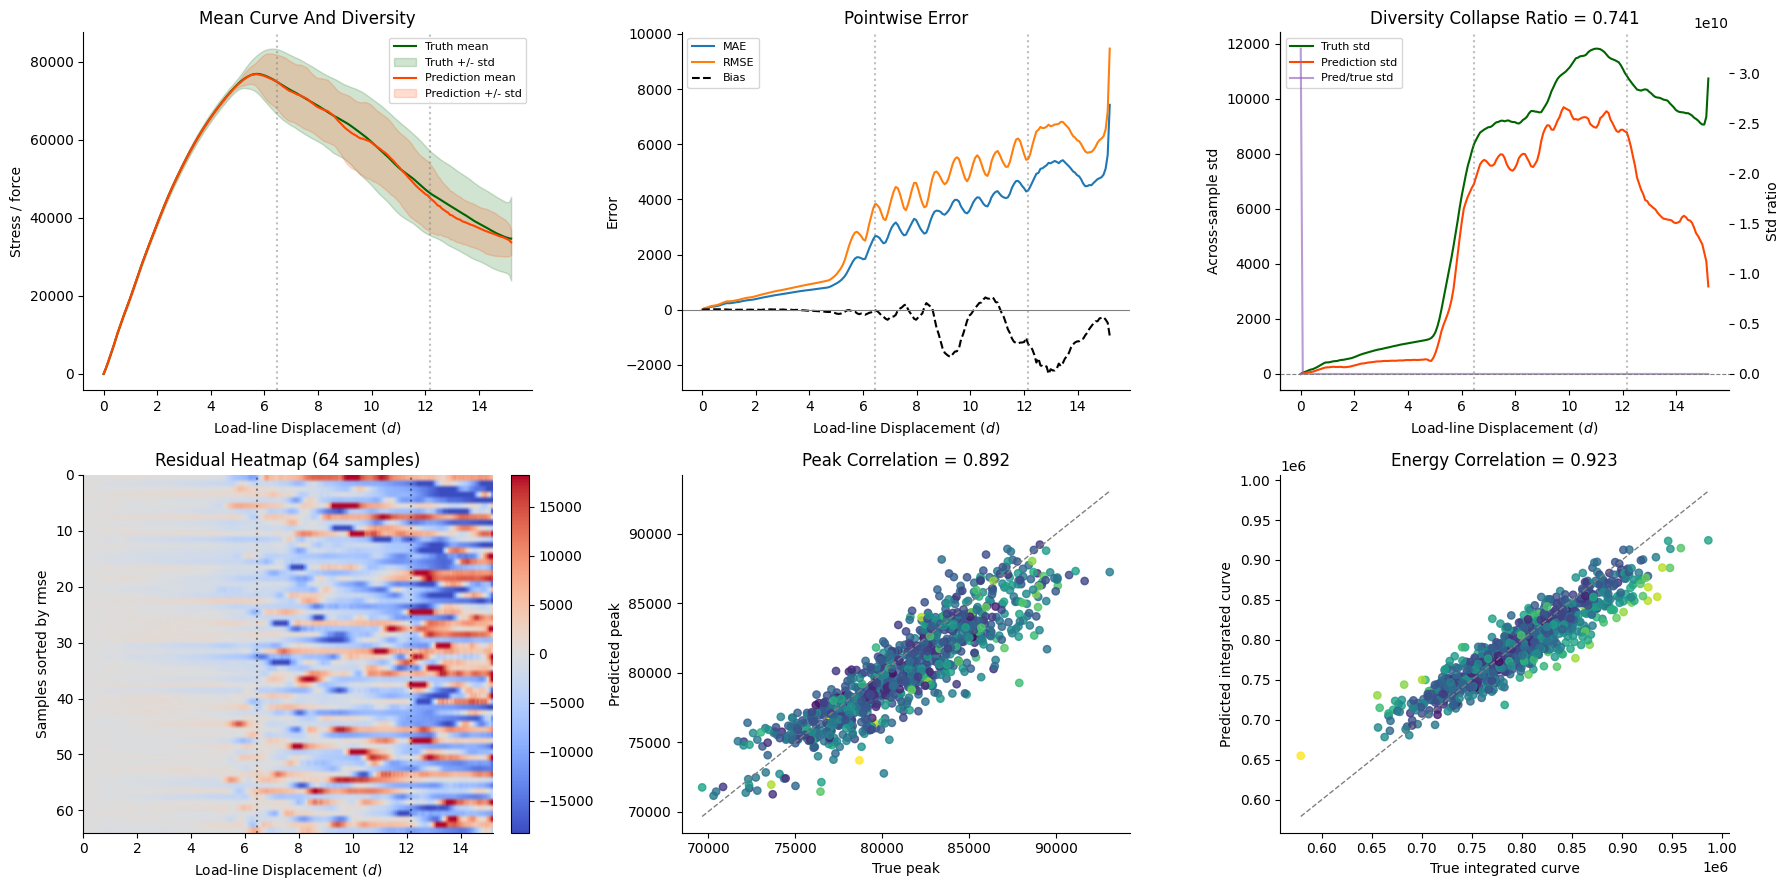

(<Figure size 1800x900 with 8 Axes>,
 array([[<Axes: title={'center': 'Mean Curve And Diversity'}, xlabel='Load-line Displacement ($d$)', ylabel='Stress / force'>,
         <Axes: title={'center': 'Pointwise Error'}, xlabel='Load-line Displacement ($d$)', ylabel='Error'>,
         <Axes: title={'center': 'Diversity Collapse Ratio = 0.741'}, xlabel='Load-line Displacement ($d$)', ylabel='Across-sample std'>],
        [<Axes: title={'center': 'Residual Heatmap (64 samples)'}, xlabel='Load-line Displacement ($d$)', ylabel='Samples sorted by rmse'>,
         <Axes: title={'center': 'Peak Correlation = 0.892'}, xlabel='True peak', ylabel='Predicted peak'>,
         <Axes: title={'center': 'Energy Correlation = 0.923'}, xlabel='True integrated curve', ylabel='Predicted integrated curve'>]],
       dtype=object))

In [24]:
DASHBOARD_MAX_SAMPLES = 64
DASHBOARD_SORT_BY = "rmse"


display_curve_main_dashboard(
    active_diag,
    data=DAT,
    mode=active_key[0] if active_key is not None else VIEW_MODE,
    max_samples=DASHBOARD_MAX_SAMPLES,
    sort_by=DASHBOARD_SORT_BY,
)


## 7. Pointwise Error And Correlations


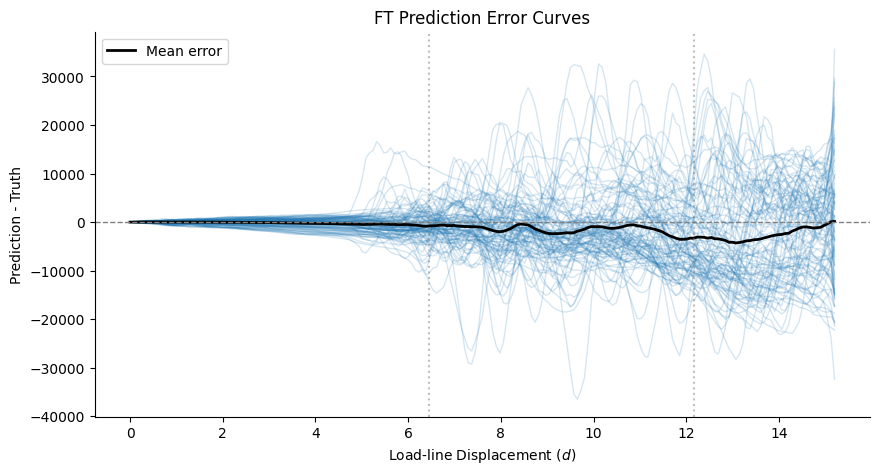

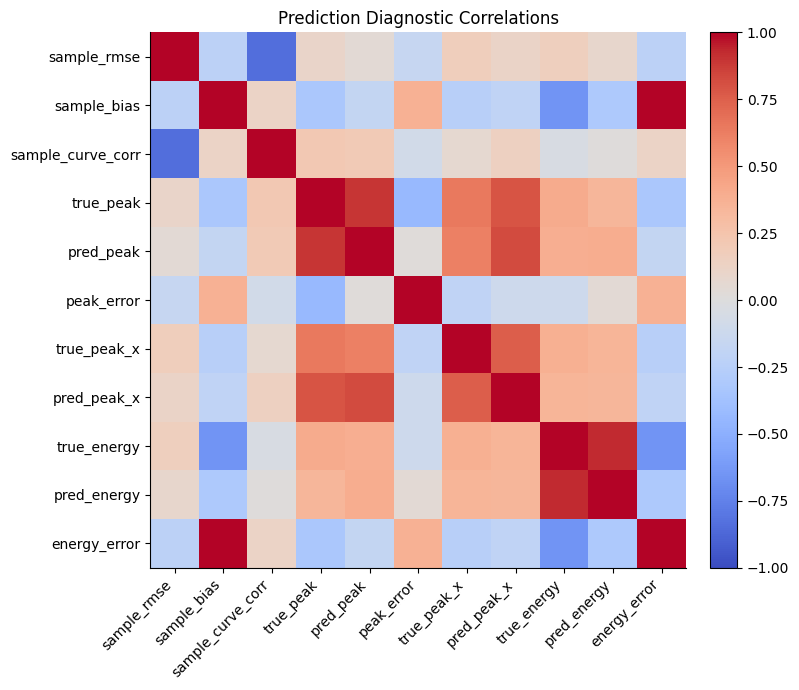

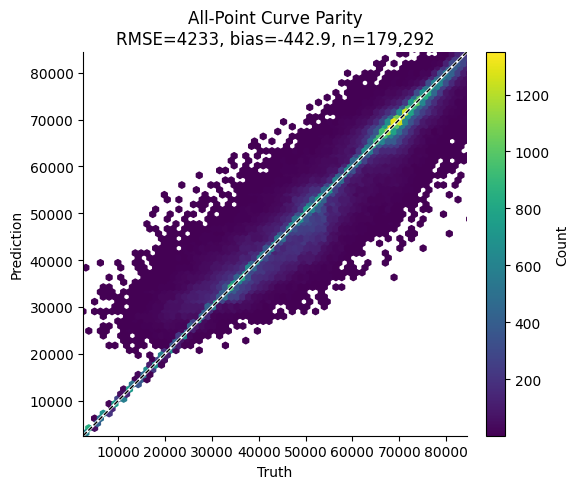

In [25]:
ERROR_CURVE_SAMPLES = 100
ERROR_CURVE_SORT_BY = "rmse"
SHOW_CORRELATION_MATRIX = True
SHOW_CURVE_PARITY = True
CURVE_PARITY_GRIDSIZE = 75
CURVE_PARITY_FIGSIZE = (6, 5)


display_curve_pointwise_summary(
    active_diag,
    data=DAT,
    mode=active_key[0] if active_key is not None else VIEW_MODE,
    max_error_curves=ERROR_CURVE_SAMPLES,
    sort_by=ERROR_CURVE_SORT_BY,
    show_correlation=SHOW_CORRELATION_MATRIX,
)

if SHOW_CURVE_PARITY:
    plot_curve_all_point_parity(
        active_diag,
        gridsize=CURVE_PARITY_GRIDSIZE,
        figsize=CURVE_PARITY_FIGSIZE,
    )


## 8. Sample-Level Error


### Best And Worst Samples By RMSE

,sample,sample_mae,sample_mse,sample_rmse,sample_bias,sample_max_abs_error,sample_curve_corr,true_peak,pred_peak,peak_error,true_peak_x,pred_peak_x,peak_x_error,true_energy,pred_energy,energy_error
133,133,1075.815625,2.799219e+06,1673.086796,88.055904,6121.142250,0.996151,79822.753629,79665.516454,-157.237175,5.776374,5.928354,0.151980,810635.558780,811973.098649,1337.539869
562,562,1303.415574,2.953507e+06,1718.577111,-868.730006,5935.737344,0.997361,85194.404467,82568.092358,-2626.312109,6.992395,6.916382,-0.076013,752629.093801,739562.157805,-13066.935996
380,380,1237.533106,3.494768e+06,1869.429886,-196.274540,6989.010651,0.995997,83125.156242,81589.191425,-1535.964818,6.764357,6.536365,-0.227993,838239.742607,835477.862518,-2761.880088
40,40,1244.232757,3.637477e+06,1907.216958,68.372139,6808.634740,0.993897,78236.086098,76629.938373,-1606.147725,5.624394,5.472369,-0.152025,769216.209357,770472.339121,1256.129764
839,839,1382.743665,3.847202e+06,1961.428447,-325.191228,7085.367256,0.994340,80600.279406,79968.801958,-631.477448,6.308372,6.156392,-0.151980,777346.242206,772647.947228,-4698.294978
214,214,5214.551266,6.069137e+07,7790.466390,-5073.815368,20454.469994,0.956879,85490.161683,82995.251524,-2494.910160,7.752385,7.296355,-0.456030,925760.115054,849030.242809,-76729.872244
791,791,4728.235227,6.081823e+07,7798.604437,-3277.716927,22924.949296,0.933964,82256.733048,84004.628713,1747.895664,6.612377,6.536365,-0.076013,940103.812163,890484.708817,-49619.103346
437,437,4706.986410,6.231899e+07,7894.237660,-4025.959498,32362.552915,0.932941,76974.511858,76477.493093,-497.018765,9.728395,5.396357,-4.332039,926171.429082,865901.254669,-60270.174413
187,187,5482.830949,6.232242e+07,7894.455054,-5368.189586,22250.616257,0.956355,79558.705215,76394.029347,-3164.675868,5.396357,5.396357,0.000000,935126.336793,853967.553529,-81158.783264
739,739,6205.289204,7.289367e+07,8537.778893,4983.510815,26198.847953,0.941883,78687.162360,73685.156496,-5002.005864,5.852387,5.168364,-0.684023,579241.817408,655147.589126,75905.771718


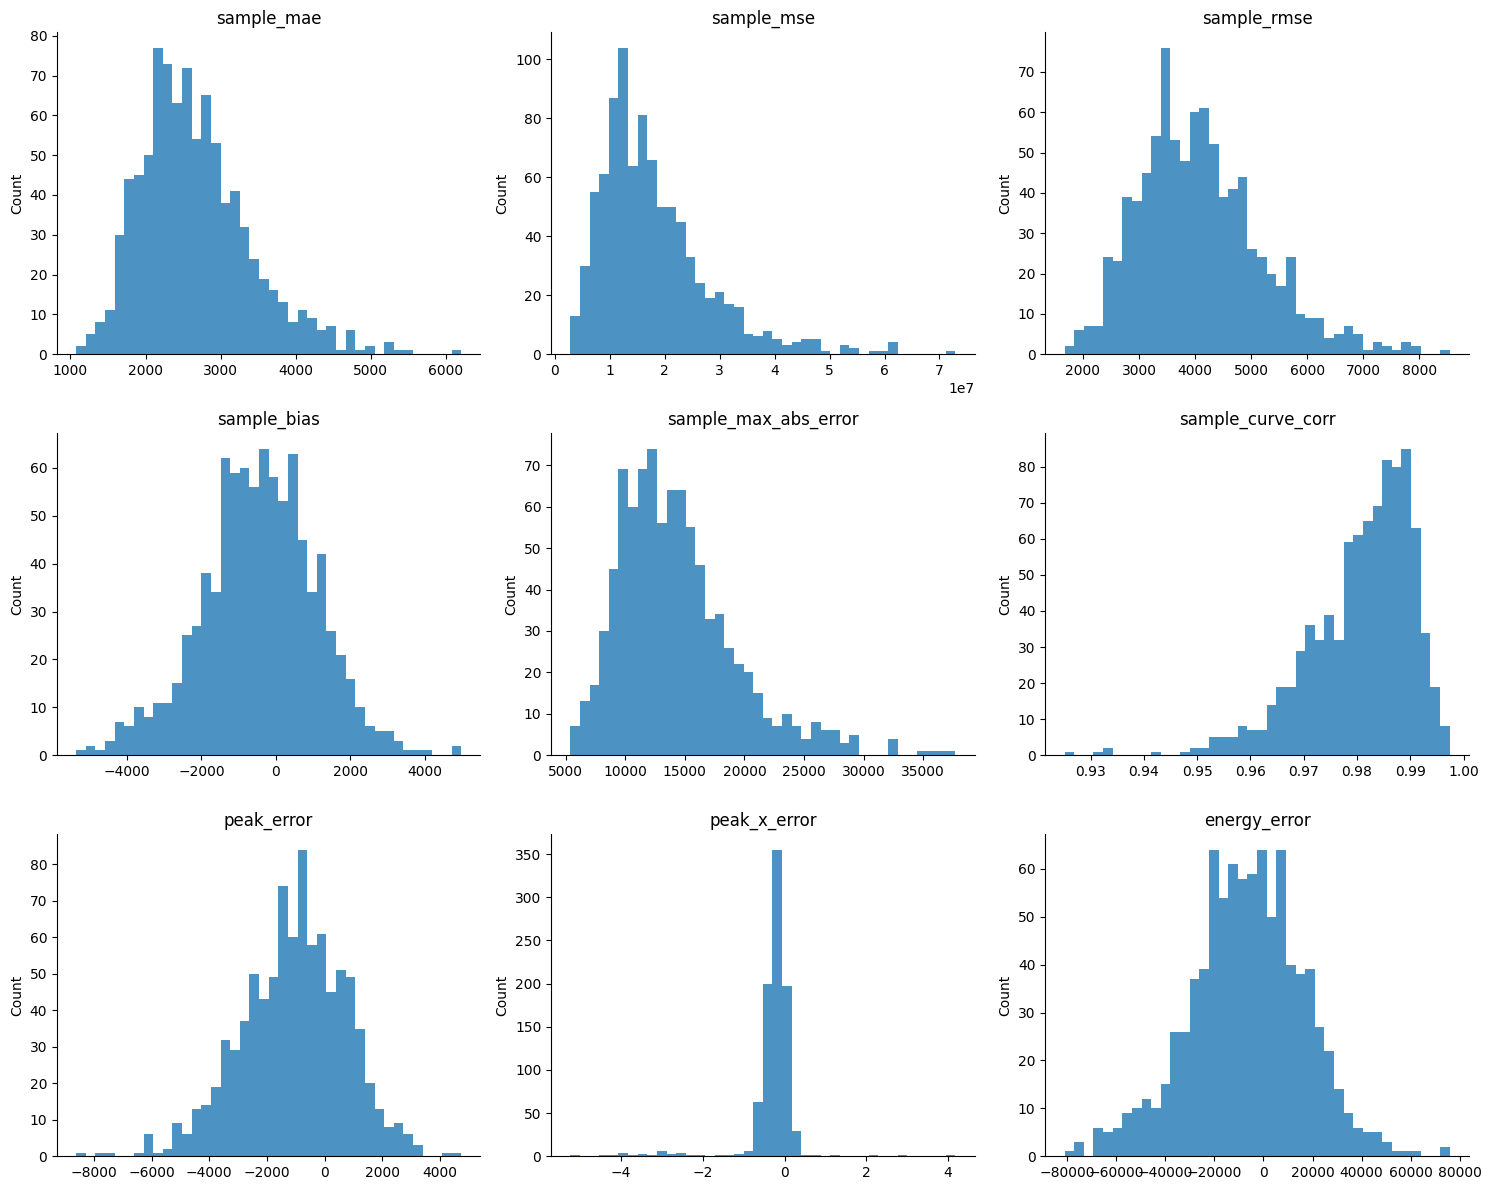

### Sample Metric Summary

,count,mean,std,min,25%,50%,75%,max
sample_mae,892.0,2.661230e+03,7.287299e+02,1.075816e+03,2.154650e+03,2.560958e+03,3.056045e+03,6.205289e+03
sample_mse,892.0,1.791410e+07,1.000855e+07,2.799219e+06,1.103718e+07,1.578945e+07,2.242831e+07,7.289367e+07
sample_rmse,892.0,4.087628e+03,1.098523e+03,1.673087e+03,3.322224e+03,3.973593e+03,4.735854e+03,8.537779e+03
sample_bias,892.0,-4.429027e+02,1.535132e+03,-5.368190e+03,-1.370858e+03,-4.061448e+02,5.490548e+02,4.983511e+03
sample_max_abs_error,892.0,1.436056e+04,4.993636e+03,5.398251e+03,1.088924e+04,1.359070e+04,1.669945e+04,3.769370e+04
sample_curve_corr,892.0,9.806606e-01,9.918821e-03,9.251100e-01,9.753083e-01,9.827504e-01,9.878871e-01,9.973606e-01
peak_error,892.0,-1.070606e+03,1.819393e+03,-8.619400e+03,-2.272814e+03,-9.422827e+02,1.822931e+02,4.736906e+03
peak_x_error,892.0,-2.717131e-01,6.548780e-01,-5.244009e+00,-3.040053e-01,-1.520252e-01,0.000000e+00,4.180015e+00
energy_error,892.0,-6.729778e+03,2.333290e+04,-8.115878e+04,-2.097546e+04,-6.249928e+03,8.182699e+03,7.590577e+04


In [26]:
SAMPLE_DISTRIBUTION_BINS = 40
SAMPLE_DISTRIBUTION_NCOLS = 3
SAMPLE_TABLE_TOP_N = 5
SAMPLE_DESCRIBE_COLUMNS = [
    "sample_mae",
    "sample_mse",
    "sample_rmse",
    "sample_bias",
    "sample_max_abs_error",
    "sample_curve_corr",
    "peak_error",
    "peak_x_error",
    "energy_error",
]


display_curve_sample_error_summary(
    active_diag,
    bins=SAMPLE_DISTRIBUTION_BINS,
    ncols=SAMPLE_DISTRIBUTION_NCOLS,
    top_n=SAMPLE_TABLE_TOP_N,
    columns=SAMPLE_DESCRIBE_COLUMNS,
)


## 9. Initial Slope, Peak, And Energy Agreement


### Initial Slope Summary

,metric,value
0,window_start_idx,0.000000
1,window_end_idx,16.000000
2,window_start_x,0.000000
3,window_end_x,1.215823
4,window_points,17.000000
5,slope_correlation,0.722076
6,slope_mae,231.864149
7,slope_rmse,297.233995
8,slope_bias,-8.984175
9,slope_median_abs_percent_error,0.948323


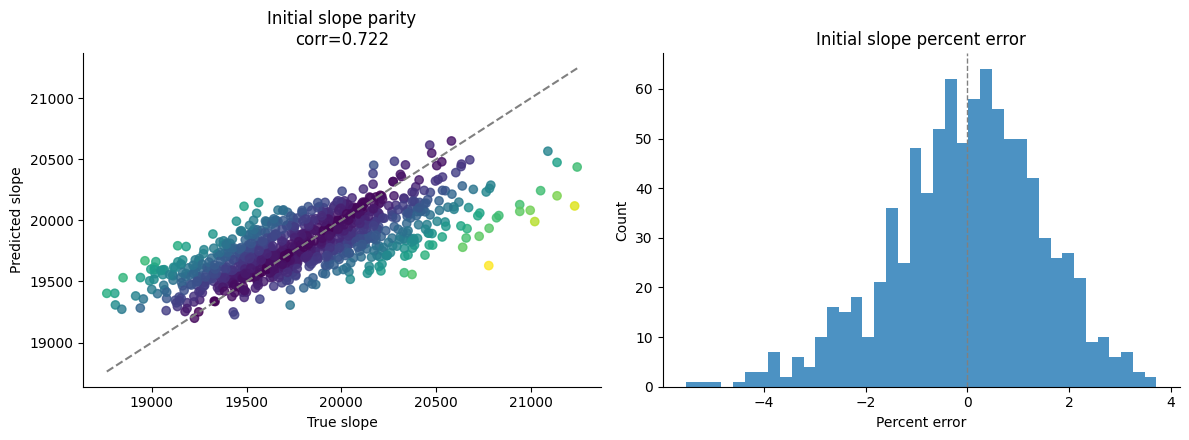

### Worst Initial Slope Samples

,sample,true_slope,pred_slope,slope_error,slope_percent_error,abs_percent_error
57,57,20778.310612,19629.949917,-1148.360695,-5.526728,5.526728
821,821,21231.516218,20118.226752,-1113.289467,-5.243570,5.243570
97,97,21021.052249,19990.450201,-1030.602049,-4.902714,4.902714
487,487,21138.648280,20201.222349,-937.425931,-4.434654,4.434654
461,461,20997.170508,20082.448212,-914.722296,-4.356407,4.356407


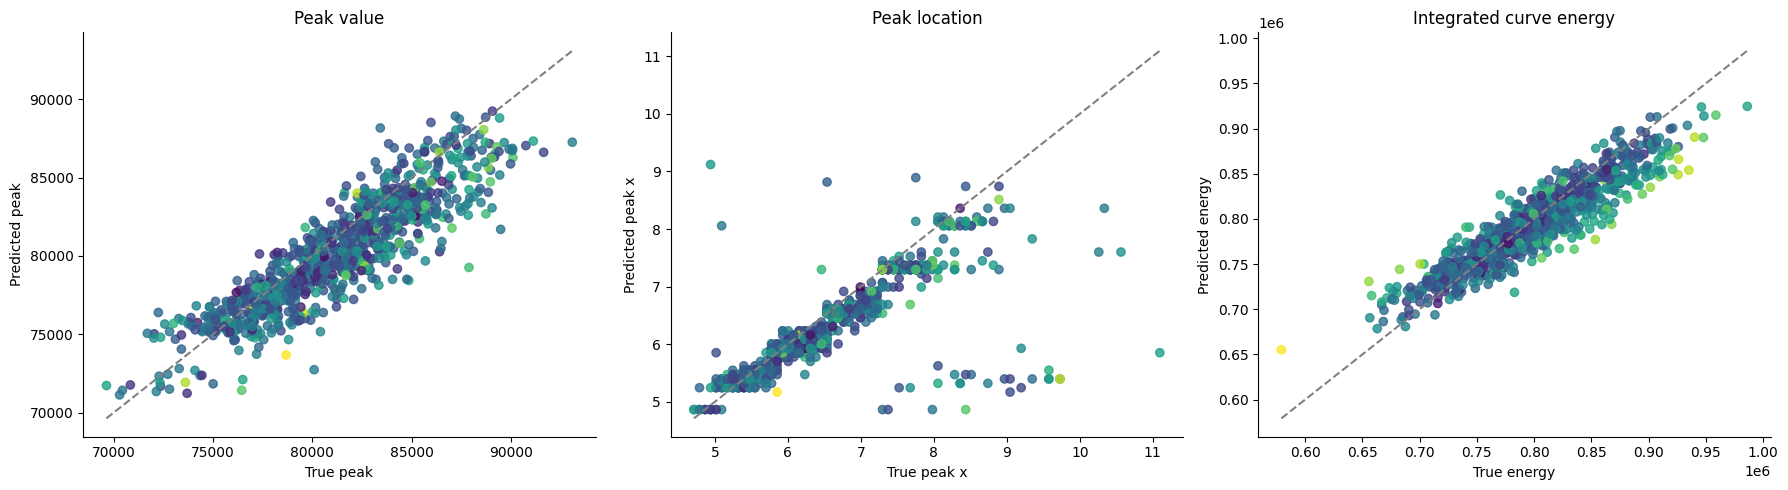

In [27]:
SHOW_INITIAL_SLOPE = True
INITIAL_SLOPE_WINDOW_FRACTION = 0.08
INITIAL_SLOPE_X_THRESHOLD = None
INITIAL_SLOPE_MIN_POINTS = 3
INITIAL_SLOPE_TOP_N = 5
SHOW_PEAK_ENERGY = True


if SHOW_INITIAL_SLOPE:
    slope_metrics_df, slope_summary = display_curve_initial_slope_summary(
        active_diag,
        window_fraction=INITIAL_SLOPE_WINDOW_FRACTION,
        x_threshold=INITIAL_SLOPE_X_THRESHOLD,
        min_points=INITIAL_SLOPE_MIN_POINTS,
        top_n=INITIAL_SLOPE_TOP_N,
    )

if SHOW_PEAK_ENERGY:
    display_curve_peak_energy_summary(active_diag)


## 10. Zone Metrics


### Zone Metrics

,zone,start_idx,end_idx,x_start,x_end,mae,mse,rmse,bias,true_std_mean,pred_std_mean,collapse_ratio
0,elastic,0,85,0.000000,6.384385,737.901936,1.772857e+06,1331.486730,-34.629336,1637.708536,1087.854398,0.664254
1,peak_region,85,160,6.460397,12.084379,3548.250779,2.346131e+07,4843.687261,-416.382695,10258.614570,8513.166344,0.829855
2,post_peak,160,201,12.160392,15.200355,5026.016151,4.123032e+07,6421.084302,-1337.835464,9896.774331,5935.551431,0.599746


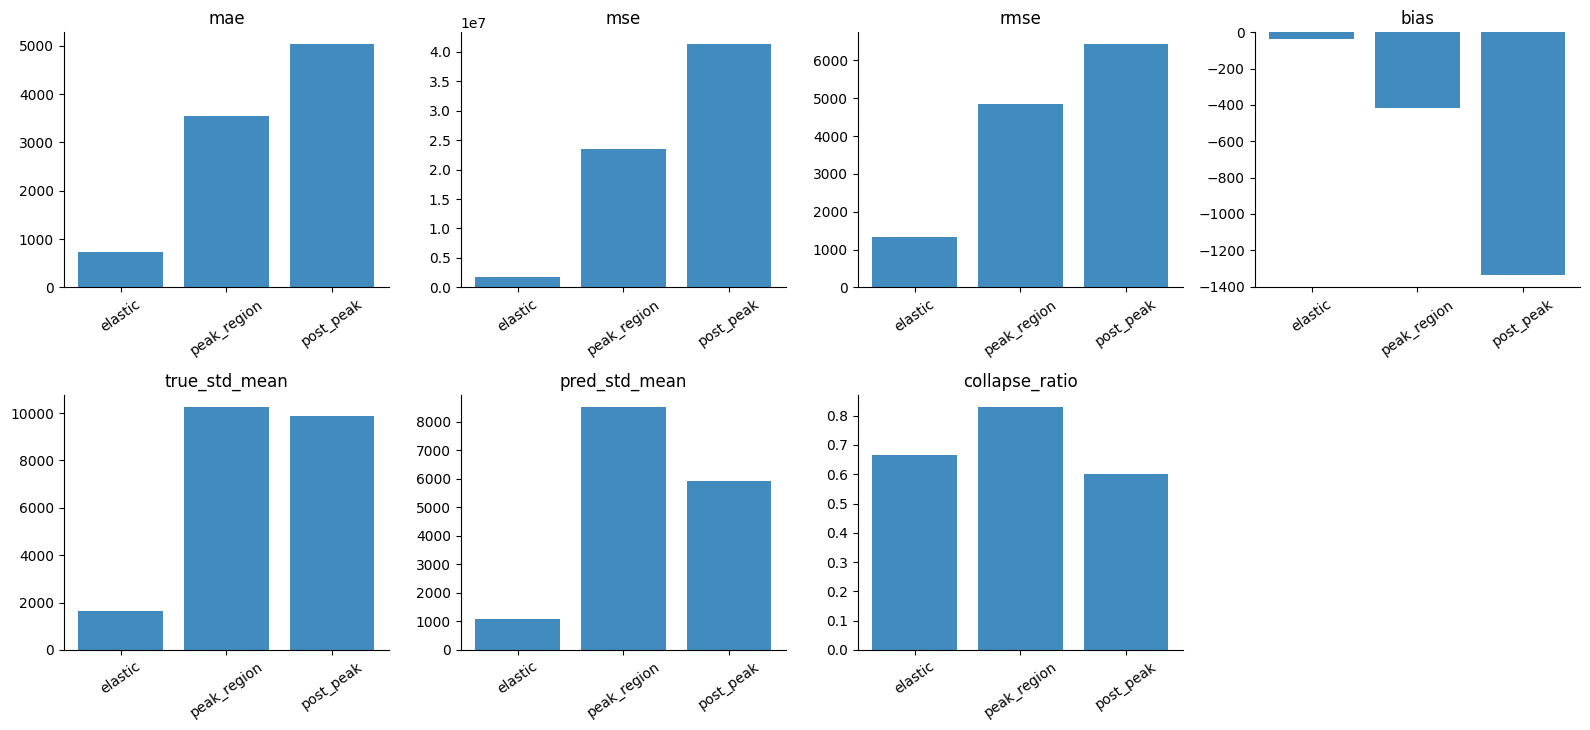

In [28]:
SHOW_ZONE_METRICS = True


if SHOW_ZONE_METRICS:
    display_curve_zone_summary(active_diag)


## 11. Selected Curve Examples


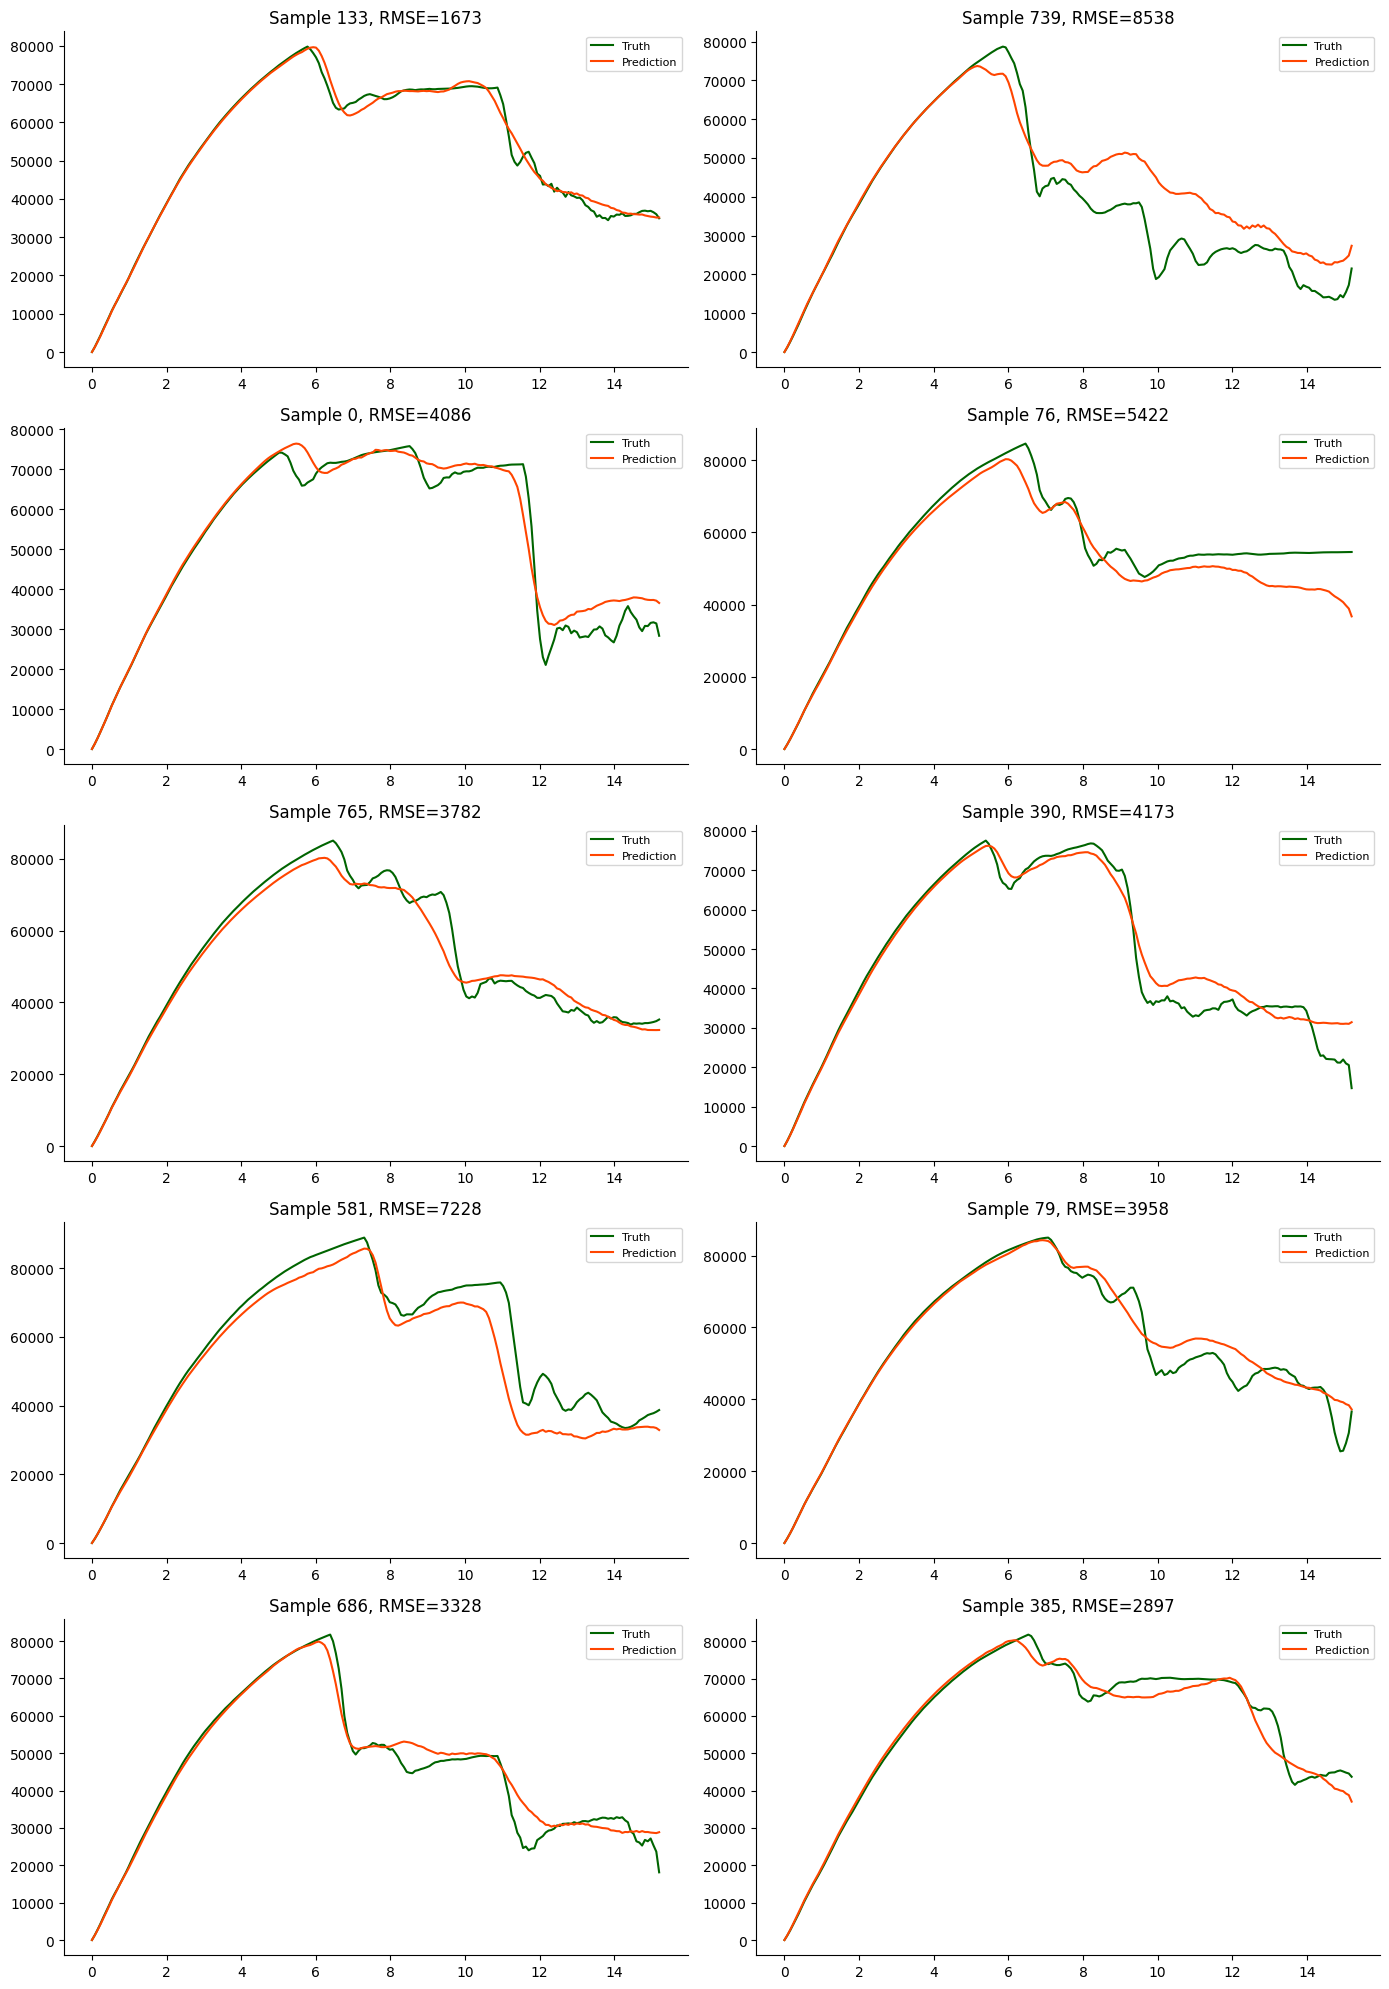

(<Figure size 1400x2000 with 10 Axes>,
 array([<Axes: title={'center': 'Sample 133, RMSE=1673'}>,
        <Axes: title={'center': 'Sample 739, RMSE=8538'}>,
        <Axes: title={'center': 'Sample 0, RMSE=4086'}>,
        <Axes: title={'center': 'Sample 76, RMSE=5422'}>,
        <Axes: title={'center': 'Sample 765, RMSE=3782'}>,
        <Axes: title={'center': 'Sample 390, RMSE=4173'}>,
        <Axes: title={'center': 'Sample 581, RMSE=7228'}>,
        <Axes: title={'center': 'Sample 79, RMSE=3958'}>,
        <Axes: title={'center': 'Sample 686, RMSE=3328'}>,
        <Axes: title={'center': 'Sample 385, RMSE=2897'}>], dtype=object))

In [29]:
SELECTED_SAMPLE = 0
RANDOM_SAMPLE_COUNT = 7
RANDOM_SEED = 42
EXAMPLE_RANK_BY = "sample_rmse"
EXAMPLE_NCOLS = 2


display_curve_sample_examples(
    active_diag,
    selected_sample=SELECTED_SAMPLE,
    random_count=RANDOM_SAMPLE_COUNT,
    random_seed=RANDOM_SEED,
    rank_by=EXAMPLE_RANK_BY,
    ncols=EXAMPLE_NCOLS,
)


## 12. Training Loss History


,mode,epoch,train_loss,val_loss
0,FT,1,2.339485,1.501399
1,FT,2,1.557642,1.421096
2,FT,3,1.485732,1.391810
3,FT,4,1.445630,1.362471
4,FT,5,1.416375,1.387193


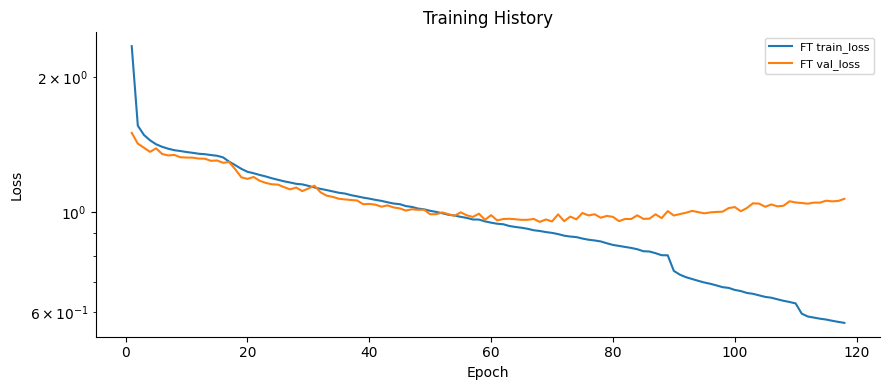

(<Figure size 900x400 with 1 Axes>,
 <Axes: title={'center': 'Training History'}, xlabel='Epoch', ylabel='Loss'>)

In [30]:
LOSS_HISTORY_METRICS = ["train_loss", "val_loss"]
LOSS_HISTORY_FIGSIZE = (9, 4)


loss_history = loaded.get("loss_history")
if loss_history is not None and hasattr(loss_history, "empty") and not loss_history.empty:
    display(loss_history.head())
plot_loss_history(loss_history, metrics=LOSS_HISTORY_METRICS, figsize=LOSS_HISTORY_FIGSIZE)


## 13. Loss Component Breakdown


,loss_index,loss_class,component,value,weighted_value
0,0,CombinedCurveLoss,mse,0.002717,0.002717
1,0,CombinedCurveLoss,weighted_mse,0.002995,0.001497
2,0,CombinedCurveLoss,derivative,5.277126,0.263856
3,0,CombinedCurveLoss,peak,0.000646,0.000162
4,0,CombinedCurveLoss,energy,0.000897,0.000090
5,0,CombinedCurveLoss,peak_location,0.002874,0.000057


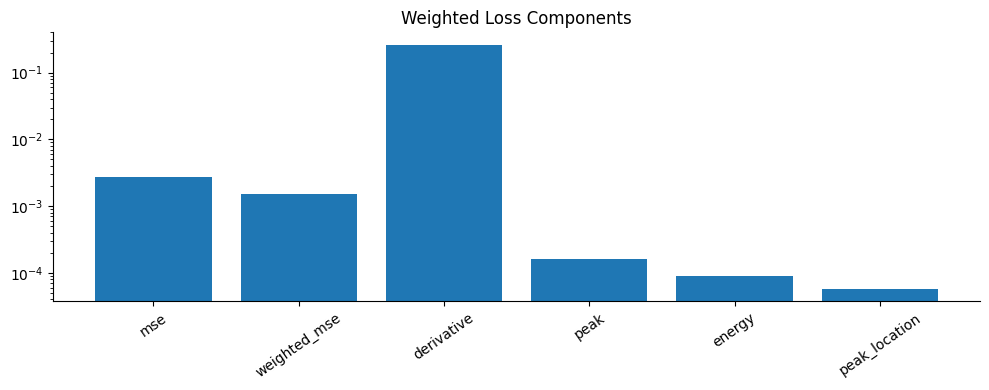

In [31]:
SHOW_LOSS_COMPONENTS = True


if SHOW_LOSS_COMPONENTS:
    loss_components_df = display_curve_loss_component_breakdown(MOD, active_diag, active_key=active_key)
